# Modelo - SBXception

Juan Muelledes Mateos - Trabajo final de Modelado Computacional, Simulacion y Optimización

## 1. Importamos las librerias necesarias

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn
import itertools
from sklearn.metrics import classification_report
from tensorflow.keras.applications import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input as base_preprocess
from tensorflow.keras.applications.convnext import preprocess_input as base_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.utils.multiclass import unique_labels
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

## 2. Cargamos las imagenes y las etiquetas

In [3]:
drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/Archivos Modelado/data.npy')
labels = np.load('/content/drive/MyDrive/Archivos Modelado/labels.npy')

train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.1,stratify=labels, random_state=42)
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size=0.1,stratify=train_labels, random_state=42)

Mounted at /content/drive


In [4]:
def random_rotation(img, angle_range=20):
    angle = np.random.uniform(-angle_range, angle_range)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          borderMode=cv2.BORDER_REFLECT_101)
def random_brightness_contrast(img):
    alpha = np.random.uniform(0.8, 1.2)  # contraste
    beta = np.random.uniform(-25, 25)    # brillo
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def add_gaussian_noise(img):
    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def random_zoom(img, zoom_range=(0.9, 1.1)):
    h, w = img.shape[:2]
    scale = np.random.uniform(*zoom_range)

    new_h, new_w = int(h*scale), int(w*scale)
    resized = cv2.resize(img, (new_w, new_h))

    if scale > 1:
        startx = (new_w - w)//2
        starty = (new_h - h)//2
        return resized[starty:starty+h, startx:startx+w]
    else:
        pad_h = (h - new_h)//2
        pad_w = (w - new_w)//2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_REFLECT_101
        )
def random_blur(img):
    k = np.random.choice([3,5])
    return cv2.GaussianBlur(img, (k,k), 0)

In [5]:
def produce_new_img_strong(img):

    augmented = []

    augmented.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_180))
    augmented.append(cv2.flip(img, 0))
    augmented.append(cv2.flip(img, 1))
    augmented.append(random_rotation(img))
    augmented.append(random_brightness_contrast(img))
    augmented.append(add_gaussian_noise(img))
    augmented.append(random_zoom(img))
    augmented.append(random_blur(img))

    return augmented

In [6]:
import cv2
from cv2 import imread, resize

def apply_augmentation_to_minority_classes(X_train, y_train_one_hot):

    augmented_images = []
    augmented_labels = []
    y_train_indices = np.argmax(y_train_one_hot, axis=1)
    for img, label_idx in zip(X_train, y_train_indices):
        augmented_images.append(img)
        augmented_labels.append(label_idx)
        if label_idx != 5 and label_idx != 2 and label_idx != 4:  # Después de ordenar, 5 es NV, la clase matyoritaria
            new_imgs = produce_new_img_strong(img)
            for new_img in new_imgs:
                augmented_images.append(new_img)
                augmented_labels.append(label_idx)

    augmented_labels_one_hot = to_categorical(augmented_labels, num_classes=7)
    return np.array(augmented_images), augmented_labels_one_hot

In [7]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.1, stratify=labels, random_state=42
)
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.111, stratify=train_labels, random_state=42
)

In [8]:
train_data, train_labels = apply_augmentation_to_minority_classes(train_data, train_labels)

print("Rango de valores en train_data:", train_data.min(), train_data.max())

train_data = (train_data / 127.5) - 1.0
val_data = (val_data / 127.5) - 1.0
test_data = (test_data / 127.5) - 1.0

print("Rango de valores en train_data:", train_data.min(), train_data.max())

Rango de valores en train_data: 0 255
Rango de valores en train_data: -1.0 1.0


## 3. Dividimos los datos a conjuntos de entrenamiento, validación y test

In [9]:
print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)
print("val_data shape:", val_data.shape)
print("val_labels shape:", val_labels.shape)
print("test_data shape:", test_data.shape)
print("test_labels shape:", test_labels.shape)

train_data shape: (16792, 224, 224, 3)
train_labels shape: (16792, 7)
val_data shape: (1001, 224, 224, 3)
val_labels shape: (1001, 7)
test_data shape: (1002, 224, 224, 3)
test_labels shape: (1002, 7)


In [10]:
class_names_mapping = {
    0: "AKIEC",
    1: "BCC",
    2: "BKL",
    3: "DF",
    4: "MEL",
    5: "NV",
    6: "VASC"
}

num_classes = train_labels.shape[1]
class_counts_train = np.sum(train_labels, axis=0)
class_counts_val = np.sum(val_labels, axis=0)
class_counts_test = np.sum(test_labels, axis=0)

class_counts_mapping = {}
for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name] = {'Train': class_counts_train[index]}

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Validation'] = class_counts_val[index]

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Test'] = class_counts_test[index]

for class_name, counts in class_counts_mapping.items():
    print(class_name)
    for set_name, count in counts.items():
        print(f" - {set_name}: {count}")

y_train_integers = np.argmax(train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_dict = {i: np.sqrt(w) for i, w in class_weight_dict.items()}

print("\n Pesos para cada clase para paliar desbalance:")
for cls, weight in class_weight_dict.items():
    print(f"Class {class_names_mapping[cls]}: {weight:.4f}")

AKIEC
 - Train: 2871.0
 - Validation: 33.0
 - Test: 33.0
BCC
 - Train: 4532.0
 - Validation: 51.0
 - Test: 51.0
BKL
 - Train: 879.0
 - Validation: 110.0
 - Test: 110.0
DF
 - Train: 1001.0
 - Validation: 12.0
 - Test: 12.0
MEL
 - Train: 891.0
 - Validation: 111.0
 - Test: 111.0
NV
 - Train: 5364.0
 - Validation: 670.0
 - Test: 671.0
VASC
 - Train: 1254.0
 - Validation: 14.0
 - Test: 14.0

 Pesos para cada clase para paliar desbalance:
Class AKIEC: 0.9141
Class BCC: 0.7275
Class BKL: 1.6520
Class DF: 1.5481
Class MEL: 1.6408
Class NV: 0.6687
Class VASC: 1.3831


# Cambios en este modelo:

Uso de función de preprocesamiento especifica para XCeption.
Creación de una arquitectura idéntica a la mencionada en el paper en el que publicarion SBXCeption.

## 4. Definimos los elementos necesarios para el entrenamiento

### 4.1 Generador de datos aumentados

In [11]:
batch_size = 16

alpha_list = [class_weight_dict[i] for i in range(num_classes)]  # ya es lista de floats

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [12]:
class MixupSequence(tf.keras.utils.Sequence):
    def __init__(self, x, y, batch_size, datagen, alpha=0.2, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.datagen = datagen
        self.alpha = alpha
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.x) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.x))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.x[batch_indices].copy()
        batch_y = self.y[batch_indices].copy()

        # Aplicar transformaciones aleatorias a cada imagen
        for i in range(len(batch_x)):
            batch_x[i] = self.datagen.random_transform(batch_x[i])

        # Mezclar con MixUp
        lam = np.random.beta(self.alpha, self.alpha)
        idx_perm = np.random.permutation(len(batch_x))
        mixed_x = lam * batch_x + (1 - lam) * batch_x[idx_perm]
        mixed_y = lam * batch_y + (1 - lam) * batch_y[idx_perm]
        return mixed_x, mixed_y

train_gen = MixupSequence(train_data, train_labels,
                          batch_size=batch_size,
                          datagen=datagen,
                          alpha=0.2)

### 4.2 Funciones de Callback

In [13]:
lr_reduce = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.5, patience = 5,mode='max', min_lr = 1e-5,verbose = 1)
early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 25, mode='max', verbose = 1)
saved_model = '/content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5'
model_chkpt = ModelCheckpoint(saved_model ,save_best_only = True, monitor = 'val_accuracy',verbose = 1)

callback_list = [early_stop, model_chkpt, lr_reduce]

### 4.3 Modelo SBXception

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.losses import CategoricalFocalCrossentropy

def build_sbxception(input_shape=(224, 224, 3), num_classes=7):
    inputs = tf.keras.Input(shape=input_shape)

    # Entry Flow
    # 1. Initial conv block
    x = layers.Conv2D(32, (3, 3), strides=(2, 2), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 2. Second conv block
    x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 3. First residual block with separable convolutions
    residual = layers.Conv2D(128, (1, 1), strides=(1, 1), padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = layers.SeparableConv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)  # Adjusted stride
    x = layers.add([x, residual])

    # 4. Second residual block
    residual = layers.Conv2D(256, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = layers.SeparableConv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = layers.add([x, residual])

    # 5. Third residual block (to 728 channels)
    residual = layers.Conv2D(728, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = layers.SeparableConv2D(728, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(728, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = layers.add([x, residual])

    # Middle Flow - The "triple section" you mentioned
    # This is typically 8-12 repeated blocks in Xception, but SBXception might have fewer
    for _ in range(3):  # Adjust this number based on paper specifics
        residual = x

        x = layers.ReLU()(x)
        x = layers.SeparableConv2D(728, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)

        x = layers.ReLU()(x)
        x = layers.SeparableConv2D(728, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)

        x = layers.ReLU()(x)
        x = layers.SeparableConv2D(728, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)

        x = layers.add([x, residual])

    # Exit Flow
    # 11-12. Transition to higher channels
    residual = layers.Conv2D(1024, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(728, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(1024, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = layers.add([x, residual])

    # 14-15. Final convolution blocks
    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(1536, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(2048, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # 16-17. Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)  # Larger dense layer
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

loss_fn = CategoricalFocalCrossentropy(alpha = alpha_list, gamma=2.0)

model = build_sbxception()
model.compile(optimizer=Adam(learning_rate = 1e-4), loss=loss_fn, metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,432 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 112, 112,  │      8,768 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 112, 112,  │     17,536 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │      8,192 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 112, 112,  │     33,920 │ add[0][0]       

 Total params: 14,875,111 (56.74 MB)

 Trainable params: 14,842,423 (56.62 MB)

 Non-trainable params: 32,688 (127.69 KB)

## 5. Entrenamos el modelo

In [15]:
epochs = 50
batch_size = 16

In [16]:
from sklearn.utils import class_weight
import numpy as np


history = model.fit(train_gen,
                    validation_data=(val_data, val_labels),
                    epochs=epochs,
                    callbacks=callback_list)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4807 - loss: 0.9845
Epoch 1: val_accuracy improved from None to 0.59241, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 373s 300ms/step - accuracy: 0.5348 - loss: 0.8777 - val_accuracy: 0.5924 - val_loss: 0.6083 - learning_rate: 1.0000e-04
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6036 - loss: 0.7424
Epoch 2: val_accuracy improved from 0.59241 to 0.65235, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.6212 - loss: 0.7180 - val_accuracy: 0.6523 - val_loss: 0.6958 - learning_rate: 1.0000e-04
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6521 - loss: 0.6620
Epoch 3: val_accuracy improved from 0.65235 to 0.66234, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5



Epoch 3: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.6667 - loss: 0.6408 - val_accuracy: 0.6623 - val_loss: 0.6350 - learning_rate: 1.0000e-04
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.7024 - loss: 0.5830
Epoch 4: val_accuracy improved from 0.66234 to 0.69331, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5


...


Epoch 23: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 216s 206ms/step - accuracy: 0.8941 - loss: 0.3002 - val_accuracy: 0.8362 - val_loss: 0.2475 - learning_rate: 2.5000e-05
Epoch 24/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8994 - loss: 0.2817
Epoch 24: val_accuracy did not improve from 0.83616
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 216s 206ms/step - accuracy: 0.8936 - loss: 0.2850 - val_accuracy: 0.7493 - val_loss: 0.3680 - learning_rate: 2.5000e-05
Epoch 25/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8924 - loss: 0.2929
Epoch 25: val_accuracy did not improve from 0.83616
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 213s 203ms/step - accuracy: 0.8918 - loss: 0.2943 - val_accuracy: 0.8122 - val_loss: 0.3571 - learning_rate: 2.5000e-05
Epoch 26/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8990 - loss: 0.2793
Epoch 26: val_accuracy improved from 0.83616 to 0.83916, saving


Epoch 26: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 217s 206ms/step - accuracy: 0.8940 - loss: 0.2901 - val_accuracy: 0.8392 - val_loss: 0.3104 - learning_rate: 2.5000e-05
Epoch 27/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9078 - loss: 0.2574
Epoch 27: val_accuracy did not improve from 0.83916
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 215s 205ms/step - accuracy: 0.9034 - loss: 0.2724 - val_accuracy: 0.8292 - val_loss: 0.2539 - learning_rate: 2.5000e-05
Epoch 28/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9020 - loss: 0.2882
Epoch 28: val_accuracy did not improve from 0.83916
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 215s 205ms/step - accuracy: 0.9074 - loss: 0.2777 - val_accuracy: 0.8362 - val_loss: 0.2900 - learning_rate: 2.5000e-05
Epoch 29/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9108 - loss: 0.2570
Epoch 29: val_accuracy improved from 0.83916 to 0.84116, saving


Epoch 29: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 221s 211ms/step - accuracy: 0.9038 - loss: 0.2740 - val_accuracy: 0.8412 - val_loss: 0.2620 - learning_rate: 2.5000e-05
Epoch 30/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9061 - loss: 0.2796
Epoch 30: val_accuracy did not improve from 0.84116
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 217s 207ms/step - accuracy: 0.9035 - loss: 0.2832 - val_accuracy: 0.8072 - val_loss: 0.3042 - learning_rate: 2.5000e-05
Epoch 31/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9037 - loss: 0.2642
Epoch 31: val_accuracy did not improve from 0.84116
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 213s 203ms/step - accuracy: 0.9061 - loss: 0.2642 - val_accuracy: 0.8302 - val_loss: 0.2675 - learning_rate: 2.5000e-05
Epoch 32/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9055 - loss: 0.2670
Epoch 32: val_accuracy did not improve from 0.84116
1050/1050 ━


Epoch 35: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 208ms/step - accuracy: 0.9200 - loss: 0.2601 - val_accuracy: 0.8671 - val_loss: 0.2528 - learning_rate: 1.2500e-05
Epoch 36/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9264 - loss: 0.2452
Epoch 36: val_accuracy did not improve from 0.86713
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 212s 202ms/step - accuracy: 0.9237 - loss: 0.2492 - val_accuracy: 0.8292 - val_loss: 0.2614 - learning_rate: 1.2500e-05
Epoch 37/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9194 - loss: 0.2408
Epoch 37: val_accuracy did not improve from 0.86713
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 211s 201ms/step - accuracy: 0.9184 - loss: 0.2508 - val_accuracy: 0.8631 - val_loss: 0.2488 - learning_rate: 1.2500e-05
Epoch 38/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9282 - loss: 0.2503
Epoch 38: val_accuracy improved from 0.86713 to 0.86913, saving


Epoch 38: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 220s 209ms/step - accuracy: 0.9265 - loss: 0.2444 - val_accuracy: 0.8691 - val_loss: 0.2672 - learning_rate: 1.2500e-05
Epoch 39/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9268 - loss: 0.2302
Epoch 39: val_accuracy did not improve from 0.86913
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 212s 202ms/step - accuracy: 0.9261 - loss: 0.2392 - val_accuracy: 0.8412 - val_loss: 0.2602 - learning_rate: 1.2500e-05
Epoch 40/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9265 - loss: 0.2624
Epoch 40: val_accuracy did not improve from 0.86913
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 216s 206ms/step - accuracy: 0.9278 - loss: 0.2578 - val_accuracy: 0.8352 - val_loss: 0.2480 - learning_rate: 1.2500e-05
Epoch 41/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9287 - loss: 0.2420
Epoch 41: val_accuracy did not improve from 0.86913
1050/1050 ━

In [ ]:
model.load_weights(saved_model)
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss="categorical_crossentropy",
              metrics=['accuracy'])

fine_lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, mode='max', min_lr=1e-8, verbose=1)
fine_early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=8, verbose=1)
fine_checkpoint = ModelCheckpoint(saved_model.replace('.h5', '_finetuned.h5'), save_best_only=True, monitor='val_accuracy', verbose=1)

fine_callbacks = [fine_checkpoint, fine_lr_reduce, fine_early_stop]

fine_tune_epochs = 15
history_fine = model.fit(datagen.flow(train_data, train_labels, batch_size=batch_size),
                         validation_data=(val_data, val_labels),
                         epochs=fine_tune_epochs,
                         callbacks=fine_callbacks)

Epoch 1/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9971 - loss: 0.0474
Epoch 1: val_accuracy improved from None to 0.90909, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 238s 182ms/step - accuracy: 0.9964 - loss: 0.0333 - val_accuracy: 0.9091 - val_loss: 0.3856 - learning_rate: 1.0000e-06
Epoch 2/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9973 - loss: 0.0159
Epoch 2: val_accuracy improved from 0.90909 to 0.91309, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/Xception_finetuned.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 182s 173ms/step - accuracy: 0.9968 - loss: 0.0155 - val_accuracy: 0.9131 - val_loss: 0.4182 - learning_rate: 1.0000e-06
Epoch 3/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9974 - loss: 0.0130
Epoch 3: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 171s 162ms/step - accuracy: 0.9974 - loss: 0.0121 - val_accuracy: 0.9131 - val_loss: 0.4443 - learning_rate: 1.0000e-06
Epoch 4/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9975 - loss: 0.0107
Epoch 4: val_accuracy did not improve from 0.91309
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 171s 163ms/step - accuracy: 0.9972 - loss: 0.0111 - val_accuracy: 0.9111 - val_loss: 0.4558 - learning_rate: 1.0000e-06
Epoch 5/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9977 - loss: 0.0104
Epoch 5: val_accuracy did not improve from 0.91309

Epoch 5: 

## 6. Evaluamos el modelo

In [ ]:
model= load_model('/content/drive/MyDrive/SC Lab/Saved Model/Final Training/SBXCeption.h5')

### 6.1 Precisión del conjunto de test

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print("Test Accuracy:", test_accuracy)

84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step - accuracy: 0.9225 - loss: 0.3185
Test Accuracy: 0.9273616671562195


### 6.2 Informe de clasificación del modelo

Classification Report

In [ ]:
predictions = model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)
report = classification_report(true_labels, predicted_labels)

print("Classification Report:")
print(report)

84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       196
           1       0.98      0.91      0.94       308
           2       0.89      0.96      0.92       660
           3       0.94      0.99      0.96        69
           4       0.92      0.93      0.93       668
           5       0.93      0.92      0.93       671
           6       0.98      0.96      0.97        85

    accuracy                           0.93      2657
   macro avg       0.95      0.93      0.93      2657
weighted avg       0.93      0.93      0.93      2657



### 6.3 Matriz de confusion

In [ ]:
cm = confusion_matrix(true_labels, np.round(predicted_labels))
cm

array([[158,   0,  20,   0,  15,   3,   0],
       [  3, 280,  18,   0,   4,   3,   0],
       [  0,   1, 635,   4,   8,  12,   0],
       [  0,   0,   0,  68,   1,   0,   0],
       [  0,   0,  19,   0, 624,  25,   0],
       [  0,   3,  21,   0,  28, 617,   2],
       [  0,   2,   0,   0,   1,   0,  82]])

Normalized confusion matrix


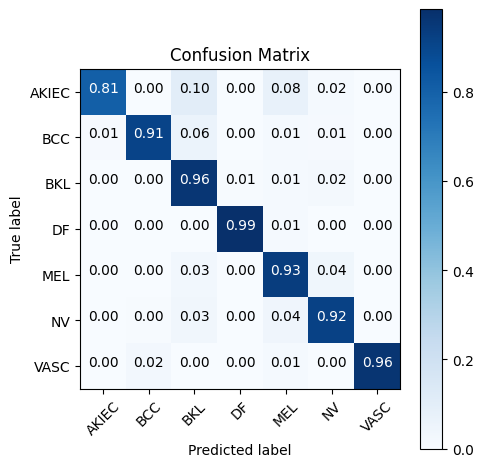

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm_plot_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)

Text(0.5, 1.0, 'Accuracy Curves')

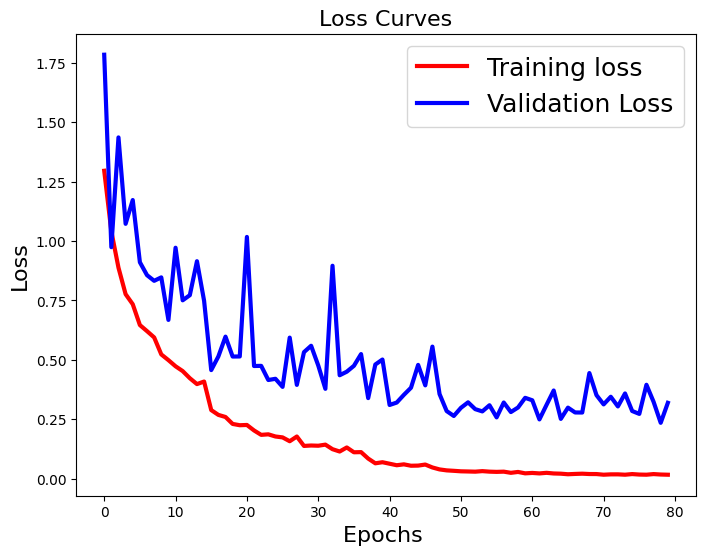

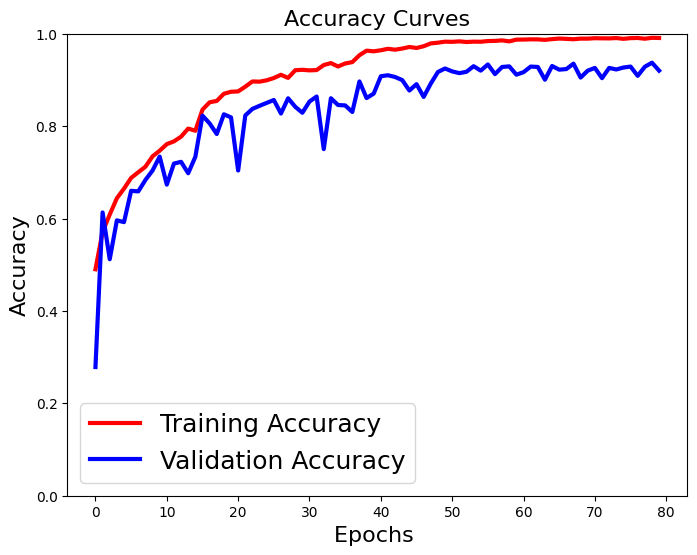

In [ ]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

# Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.ylim(0, 1)
plt.title('Accuracy Curves',fontsize=16)